---
title: "The linear driving force: where Glueckauf's 15 comes from, and when it fails"
description: "One number stands in for a whole diffusion equation in most adsorption models. Solving the sphere it approximates shows exactly what the shortcut costs, and when."
categories: [sec:J, struct:S3, struct:S4, tier:T0, data:tier6, phase:gas-solid]
date: 2026-07-27
---

# The linear driving force: where Glueckauf's 15 comes from, and when it fails

**Catalog ID:** `J1.5` · **Structures:** `S3` (1-D BVP), `S4` (1-D transient PDE) · **Tier:** T0

Almost every adsorption, ion-exchange and chromatography model replaces
diffusion inside the particle with a single first-order relaxation. The constant
in it is $15D/r^2$, and the 15 has been carried forward since 1955 largely
without being re-examined.

## Background

Model a packed adsorption column honestly and you have a problem inside a
problem: a bed equation in the axial coordinate, and inside every particle a
diffusion equation in the radial one. Solving the inner problem at every axial
node and every time step is expensive, and in 1955 it was impossible.

Glueckauf's shortcut is to keep only the particle's *mean* loading $\bar q$ and
let it relax towards the surface value:

$$
\frac{\mathrm{d}\bar q}{\mathrm{d}t} = k\,(q^{*} - \bar q).
$$

The whole radial profile collapses into one number. The question the paper
answers is what $k$ should be, and his answer — $k = 15D/r^2$ — is the reason
this is called the *linear driving force* approximation and why the 15 turns up
in essentially every subsequent adsorption model.

The paper is careful about the limits: Glueckauf compares four candidate
expressions and concludes that the LDF is "fully adequate" for linear or
moderately curved isotherms held near equilibrium, and *not* adequate for steep
fronts or nearly irreversible exchange. This page reproduces the underlying
comparison and puts numbers on it.

## The published model

**The real problem.** Diffusion into a sphere of radius $r$ with a step change
of surface concentration to $q^{*}$ at $t = 0$:

$$
\frac{\partial q}{\partial t} = \frac{D}{r'^{2}}\frac{\partial}{\partial r'}
\!\left(r'^{2}\frac{\partial q}{\partial r'}\right),
\qquad \left.\frac{\partial q}{\partial r'}\right|_{0} = 0,
\qquad q(r,t) = q^{*} .
$$

Its exact solution for the volume-mean loading is a classical series:

$$
\frac{\bar q}{q^{*}} = 1 - \frac{6}{\pi^{2}}\sum_{n=1}^{\infty}\frac{1}{n^{2}}
\exp\!\left(-n^{2}\pi^{2}\,\tau\right),\qquad \tau = \frac{Dt}{r^{2}} .
$$

**Glueckauf's approximation** (his Eq. 24), written with $E = D/r^{2}$:

$$
\frac{\mathrm{d}\bar q}{\mathrm{d}(Et)} = 15\,(q^{*} - \bar q)
\qquad\Longrightarrow\qquad
\frac{\bar q}{q^{*}} = 1 - \mathrm{e}^{-15\tau}.
$$

**Where 15 comes from.** Assume the profile inside the particle is parabolic,
$q = a + b(r'/r)^2$. Then $q^{*} - \bar q = \tfrac{2}{5}b$ while the surface
flux gives $\mathrm{d}\bar q/\mathrm{d}t = 6Db/r^{2}$, and eliminating $b$
leaves exactly $15D/r^{2}$.

**But no constant can be right everywhere**, and that is structural rather than
a matter of picking better. At short times the solute has only penetrated a thin
shell, uptake grows as $\sqrt{\tau}$, and no exponential can match a square
root — the implied coefficient diverges. At long times the exact solution decays
into its slowest eigenmode, $\exp(-\pi^{2}\tau)$, so the coefficient tends to
$\pi^{2} \approx 9.87$. Glueckauf's 15 is the parabolic-profile value sitting
between those two limits. The section at the end makes this concrete.

## Parameters and assumptions

**Assumptions:** a spherical particle; constant diffusivity; a step change in
surface concentration held constant thereafter; no external film resistance; a
linear isotherm, so the surface value is fixed rather than coupled to a bulk
that is itself changing.

Everything is dimensionless. Lengths are in particle radii and time is
$\tau = Dt/r^{2}$, so **there are no parameters left at all** — the comparison
between the exact solution and the LDF is universal, which is why one number
can be argued about for seventy years.

**What serves as data.** The sources here are analytical: the series solution
is exact, and $15D/r^2$ is a published approximation to it. This page is
provenance tier 6, like [`B1.1`](../B1.1-thiele-weisz-hicks/) and
[`F3.1`](../F3.1-hatta-regimes/). Glueckauf's own Tables 3–5 tabulate his
numerical comparison, but this 1955 scan loses decimal points wholesale — it
renders 0.8647 as `8647` and 0.0279 as `*0279` — so they are not transcribed
here. Nothing is lost by that: the exact series is a stronger reference than his
tabulated approximation to it.

In [1]:
try:
    import pymrm
except ImportError:
    %pip install -q pymrm pyyaml

In [2]:
import sys, urllib.request
from pathlib import Path

if not any("shared" in p for p in sys.path):
    local = Path.cwd()
    for _ in range(4):
        if (local / "shared" / "gallery_utils.py").is_file():
            sys.path.insert(0, str(local / "shared")); break
        local = local.parent
    else:
        url = ("https://raw.githubusercontent.com/computational-chemical-engineering/"
               "pymrm-gallery/main/shared/gallery_utils.py")
        urllib.request.urlretrieve(url, "gallery_utils.py")
        sys.path.insert(0, ".")

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize_scalar
from scipy.sparse import eye_array
from scipy.sparse.linalg import splu
from pymrm import construct_grad, construct_div
from gallery_utils import report_agreement

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})

## The data

None to load: the reference is the analytic series above, evaluated to as many
terms as needed. The check that matters is that the pymrm solution of the PDE
converges onto it.

## PyMRM implementation

The particle is a sphere, so `nu=2` in `construct_div` — that single argument is
the whole of the spherical geometry. The rest is a standard transient diffusion
problem: constant operators built once, backward Euler, and the matrix
factorised once because nothing in it changes.

The volume-mean loading is what the LDF tracks, so it is worth being careful
about: the weights are $3r'^2\,\mathrm{d}r'/r^3$, which sum to one.

In [3]:
def exact_uptake(tau, n_terms=600):
    """Classical series for the volume-mean loading in a sphere."""
    tau = np.atleast_1d(np.asarray(tau, float))
    n = np.arange(1, n_terms + 1)[:, None]
    s = np.sum(np.exp(-n ** 2 * np.pi ** 2 * tau) / n ** 2, axis=0)
    return 1.0 - 6.0 / np.pi ** 2 * s


def ldf_uptake(tau, k=15.0):
    """Glueckauf Eq. 24 integrated for a step in surface concentration."""
    return 1.0 - np.exp(-k * np.asarray(tau, float))


class Particle:
    """Transient diffusion into a sphere, dimensionless: radius 1, D = 1."""

    def __init__(self, n_r=200):
        self.r_f = np.linspace(0.0, 1.0, n_r + 1)
        self.r_c = 0.5 * (self.r_f[:-1] + self.r_f[1:])
        self.n_r = n_r
        # outward normal, so a dq/dn + b q = d
        # centre: symmetry, dq/dn = 0     -> a=1, b=0, d=0
        # surface: q = q* = 1             -> a=0, b=1, d=1
        bc = ({"a": 1.0, "b": 0.0, "d": 0.0}, {"a": 0.0, "b": 1.0, "d": 1.0})
        grad, grad_bc = construct_grad((n_r,), self.r_f, self.r_c, bc)
        div = construct_div((n_r,), self.r_f, nu=2)      # nu=2: spherical
        self.jac = -(div @ grad)
        self.rhs0 = (div @ grad_bc).toarray().ravel()
        self.w = 3.0 * self.r_c ** 2 * np.diff(self.r_f)  # volume weights, sum 1
        self.reset()

    def reset(self):
        self.q = np.zeros(self.n_r)
        self.tau = 0.0
        self._dt = None

    def step(self, dt, n=1):
        if self._dt != dt:
            self._lu = splu((eye_array(self.n_r, format="csc") / dt + self.jac).tocsc())
            self._dt = dt
        for _ in range(n):
            self.q = self._lu.solve(self.q / dt + self.rhs0)
            self.tau += dt

    def run(self, taus, dt=2e-5):
        """Mean loading at each requested tau, marching from zero."""
        self.reset()
        out, profiles = [], {}
        for target in np.atleast_1d(taus):
            n = int(round((target - self.tau) / dt))
            if n > 0:
                self.step(dt, n)
            out.append(float(self.w @ self.q))
            profiles[float(target)] = self.q.copy()
        return np.array(out), profiles


TAUS = np.array([0.001, 0.002, 0.005, 0.01, 0.02, 0.05, 0.1, 0.2, 0.3, 0.5])
p = Particle()
num, profiles = p.run(TAUS)
ex = exact_uptake(TAUS)
print(f"volume weights sum to {p.w.sum():.6f}")
print(f"\n{'tau':>7}{'exact':>10}{'pymrm':>10}{'rel err':>11}{'LDF 15':>10}{'LDF err':>10}")
for t, e, n_, l in zip(TAUS, ex, num, ldf_uptake(TAUS)):
    print(f"{t:>7.3f}{e:>10.5f}{n_:>10.5f}{abs(n_-e)/e:>11.2e}{l:>10.5f}"
          f"{(l-e)/e*100:>9.1f}%")

volume weights sum to 0.999994

    tau     exact     pymrm    rel err    LDF 15   LDF err
  0.001   0.10405   0.10377   2.65e-03   0.01489    -85.7%
  0.002   0.14539   0.14519   1.36e-03   0.02955    -79.7%
  0.005   0.22437   0.22424   5.71e-04   0.07226    -67.8%
  0.010   0.30851   0.30842   3.02e-04   0.13929    -54.9%
  0.020   0.41873   0.41866   1.63e-04   0.25918    -38.1%
  0.050   0.60694   0.60689   7.65e-05   0.52763    -13.1%
  0.100   0.77048   0.77044   4.64e-05   0.77687      0.8%
  0.200   0.91550   0.91547   2.80e-05   0.95021      3.8%
  0.300   0.96852   0.96851   1.78e-05   0.98889      2.1%
  0.500   0.99563   0.99562   8.88e-06   0.99945      0.4%


## Results

The left panel is the comparison Glueckauf's Fig. 2 makes qualitatively. The
right panel is why it matters: the profile inside the particle is only parabolic
for a moment, and the LDF is built on the assumption that it always is.

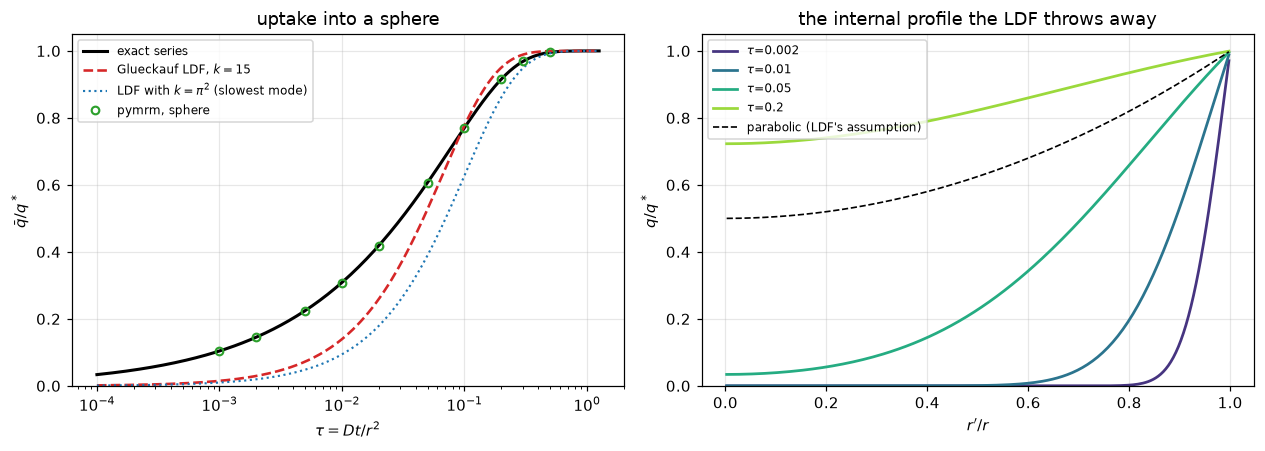

the LDF crosses the exact curve at tau = 0.0912
  below it the LDF under-predicts uptake, above it over-predicts


In [4]:
tau_fine = np.logspace(-4, 0.1, 260)
ex_fine = exact_uptake(tau_fine)

fig, axes = plt.subplots(1, 2, figsize=(11.6, 4.2))
axes[0].semilogx(tau_fine, ex_fine, color="k", lw=2.0, label="exact series")
axes[0].semilogx(tau_fine, ldf_uptake(tau_fine), color="tab:red", lw=1.7,
                 ls="--", label=r"Glueckauf LDF, $k=15$")
axes[0].semilogx(tau_fine, ldf_uptake(tau_fine, np.pi ** 2), color="tab:blue",
                 lw=1.4, ls=":", label=r"LDF with $k=\pi^2$ (slowest mode)")
axes[0].plot(TAUS, num, "o", ms=5, mfc="none", color="tab:green", mew=1.4,
             label="pymrm, sphere")
axes[0].set(xlabel=r"$\tau = Dt/r^2$", ylabel=r"$\bar q/q^*$", ylim=(0, 1.05),
            title="uptake into a sphere")
axes[0].legend(fontsize=8, loc="upper left")

for tau, col in zip((0.002, 0.01, 0.05, 0.2),
                    plt.cm.viridis(np.linspace(0.15, 0.85, 4))):
    axes[1].plot(p.r_c, profiles[tau], color=col, lw=1.8, label=fr"$\tau$={tau}")
para = 1 - (1 - p.r_c ** 2) * 0.5
axes[1].plot(p.r_c, para, "k--", lw=1.1, label="parabolic (LDF's assumption)")
axes[1].set(xlabel=r"$r'/r$", ylabel=r"$q/q^*$", ylim=(0, 1.05),
            title="the internal profile the LDF throws away")
axes[1].legend(fontsize=8, loc="upper left")
fig.tight_layout()
plt.show()

d = ldf_uptake(tau_fine) - ex_fine
sign_change = np.nonzero(np.diff(np.sign(d)))[0]
cross = tau_fine[sign_change[0]] if len(sign_change) else np.nan
print(f"the LDF crosses the exact curve at tau = {cross:.4f}")
print("  below it the LDF under-predicts uptake, above it over-predicts")

## Validation

Three checks: the solver against the exact series, the discretisation against
itself, and the approximation against what it approximates.

In [5]:
# 1. pymrm against the exact series, refined. Spherical geometry with a
#    Dirichlet surface: the scheme should be second order in dr.
print("1. pymrm vs the exact series (tau = 0.05), grid refinement")
print("   (backward Euler is first order in dt, so refining dr alone runs into")
print("    a temporal error floor -- check 2 measures that floor directly)")
target = np.array([0.05])
e_ref = float(exact_uptake(target)[0])
prev = None
for n_r in (25, 50, 100, 200, 400):
    v = float(Particle(n_r=n_r).run(target, dt=2e-5)[0][0])
    rel = abs(v - e_ref) / e_ref
    rate = "" if prev is None else f"   ratio {prev/rel:5.2f}"
    print(f"   n_r = {n_r:4d}   qbar = {v:.7f}   rel err {rel:.2e}{rate}")
    prev = rel
print("   the ratio falls away from 4 as the dt error takes over, as expected")

# 2. time-step independence at the same point
print("\n2. time-step independence (n_r = 200, tau = 0.05)")
for dt in (2e-4, 1e-4, 5e-5, 2e-5):
    v = float(Particle(n_r=200).run(target, dt=dt)[0][0])
    print(f"   dt = {dt:8.1e}   qbar = {v:.7f}   rel err {abs(v-e_ref)/e_ref:.2e}")

worst_solver = max(abs(n_ - e) / e for n_, e in zip(num, ex))
print(f"\n   worst relative error over the whole tau range: {worst_solver:.2e}")

1. pymrm vs the exact series (tau = 0.05), grid refinement
   (backward Euler is first order in dt, so refining dr alone runs into
    a temporal error floor -- check 2 measures that floor directly)
   n_r =   25   qbar = 0.6063920   rel err 9.02e-04
   n_r =   50   qbar = 0.6067691   rel err 2.81e-04   ratio  3.21
   n_r =  100   qbar = 0.6068680   rel err 1.18e-04   ratio  2.38
   n_r =  200   qbar = 0.6068933   rel err 7.65e-05   ratio  1.55
   n_r =  400   qbar = 0.6068998   rel err 6.59e-05   ratio  1.16
   the ratio falls away from 4 as the dt error takes over, as expected

2. time-step independence (n_r = 200, tau = 0.05)
   dt =  2.0e-04   qbar = 0.6065528   rel err 6.38e-04
   dt =  1.0e-04   qbar = 0.6067420   rel err 3.26e-04
   dt =  5.0e-05   qbar = 0.6068366   rel err 1.70e-04
   dt =  2.0e-05   qbar = 0.6068933   rel err 7.65e-05

   worst relative error over the whole tau range: 2.65e-03


In [6]:
# 3. What the approximation costs. Errors are quoted on the FRACTIONAL UPTAKE,
#    which is what a breakthrough calculation propagates.
print("3. Glueckauf's LDF against the exact solution")
err = ldf_uptake(tau_fine) - ex_fine
print(f"   worst absolute error in qbar/q*      {np.max(np.abs(err)):.4f}"
      f"  at tau = {tau_fine[np.argmax(np.abs(err))]:.4f}")
for lo, hi, name in ((1e-4, 0.01, "early  tau < 0.01"),
                     (0.01, 0.1, "middle 0.01-0.1 "),
                     (0.1, 1.0, "late   tau > 0.1 ")):
    m = (tau_fine >= lo) & (tau_fine < hi)
    if m.any():
        print(f"   {name}: max |dqbar| {np.max(np.abs(err[m])):.4f}"
              f"   max relative {np.max(np.abs(err[m]/ex_fine[m]))*100:6.1f} %")

# 4. the two constants the problem pulls towards
slow = np.polyfit(tau_fine[tau_fine > 0.3],
                  np.log(1 - ex_fine[tau_fine > 0.3]), 1)[0]
print(f"\n4. the long-time decay constant of the exact solution: {-slow:.4f}")
print(f"   pi^2 = {np.pi**2:.4f}  ->  the tail wants ~9.87, not 15")

report_agreement("J1.5", {
    "solver_worst_rel_err": worst_solver,
    "solver_rel_err_n400": abs(float(Particle(n_r=400).run(target, dt=2e-5)[0][0])
                               - e_ref) / e_ref,
    "ldf_worst_abs_err": float(np.max(np.abs(err))),
    "ldf_max_rel_err_early": float(np.max(np.abs(err[tau_fine < 0.01]
                                                 / ex_fine[tau_fine < 0.01]))),
    "long_time_decay_constant": float(-slow),
})

3. Glueckauf's LDF against the exact solution
   worst absolute error in qbar/q*      0.1701  at tau = 0.0119
   early  tau < 0.01: max |dqbar| 0.1691   max relative   95.5 %
   middle 0.01-0.1 : max |dqbar| 0.1701   max relative   54.3 %
   late   tau > 0.1 : max |dqbar| 0.0358   max relative    4.0 %

4. the long-time decay constant of the exact solution: 9.8696
   pi^2 = 9.8696  ->  the tail wants ~9.87, not 15
Agreement metrics for J1.5:
  solver_worst_rel_err     = 0.0026465
  solver_rel_err_n400      = 6.5901e-05
  ldf_worst_abs_err        = 0.1701
  ldf_max_rel_err_early    = 0.95533
  long_time_decay_constant = 9.8696


{'page': 'J1.5',
 'metrics': {'solver_worst_rel_err': 0.0026464700842623954,
  'solver_rel_err_n400': 6.590068082348053e-05,
  'ldf_worst_abs_err': 0.17009997913329455,
  'ldf_max_rel_err_early': 0.955325957230834,
  'long_time_decay_constant': 9.869615716446221}}

## What pymrm adds

Glueckauf argued from tabulated comparisons at a handful of points. With the
exact solution in hand the question can be put directly: **at each instant, what
coefficient would the LDF have to use to be right?**

$$
k_{\mathrm{eff}}(\tau) = \frac{\mathrm{d}\bar q/\mathrm{d}\tau}{q^{*}-\bar q}
$$

If any single constant were correct, this would be flat. It is not, and the way
it fails is the whole story.

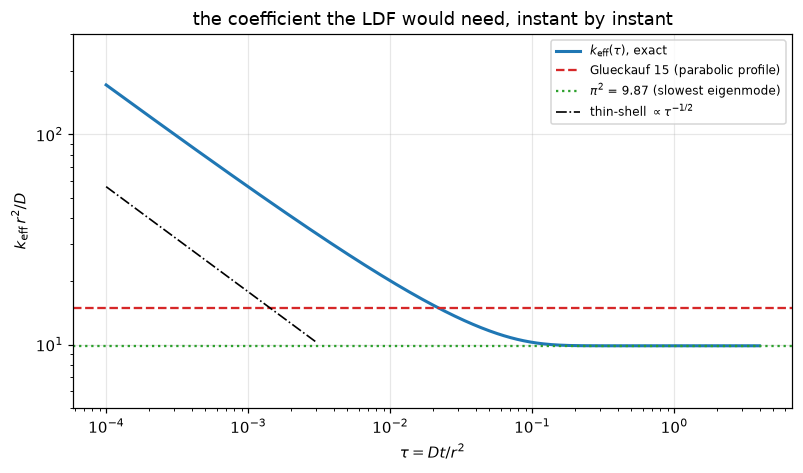

k_eff passes through 15 at tau = 0.0219   (uptake there is 44 % complete)
k_eff at tau = 3.98: 9.8696   -> pi^2 = 9.8696   (0.000 % from it)
below tau = 1e-3 it still exceeds 57 and is climbing like tau^-1/2 — no constant can follow that


In [7]:
def k_effective(tau, n_terms=600):
    # The coefficient the LDF would need at each instant, in closed form.
    # Both the deficit q* - qbar and its rate come straight from the series, so
    # nothing is differentiated numerically and nothing is formed as
    # 1 - (1 - eps), which loses all precision once the particle is nearly full.
    tau = np.atleast_1d(np.asarray(tau, float))
    n = np.arange(1, n_terms + 1)[:, None]
    e = np.exp(-n ** 2 * np.pi ** 2 * tau)
    deficit = 6.0 / np.pi ** 2 * np.sum(e / n ** 2, axis=0)   # q* - qbar
    rate = 6.0 * np.sum(e, axis=0)                            # d qbar / d tau
    return rate / deficit


tau_k = np.logspace(-4, 0.6, 400)
k_eff = k_effective(tau_k)
q = exact_uptake(tau_k)

fig, ax = plt.subplots(figsize=(7.4, 4.4))
ax.loglog(tau_k, k_eff, color="tab:blue", lw=2.0, label=r"$k_{\mathrm{eff}}(\tau)$, exact")
ax.axhline(15.0, color="tab:red", lw=1.5, ls="--", label="Glueckauf 15 (parabolic profile)")
ax.axhline(np.pi ** 2, color="tab:green", lw=1.5, ls=":",
           label=r"$\pi^2$ = 9.87 (slowest eigenmode)")
ax.loglog(tau_k[tau_k < 3e-3], 1.0 / np.sqrt(np.pi * tau_k[tau_k < 3e-3]),
          color="k", lw=1.1, ls="-.", label=r"thin-shell $\propto\tau^{-1/2}$")
ax.set(xlabel=r"$\tau = Dt/r^2$", ylabel=r"$k_{\mathrm{eff}}\,r^2/D$",
       ylim=(5, 300), title="the coefficient the LDF would need, instant by instant")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

i15 = int(np.argmin(np.abs(k_eff - 15.0)))
print(f"k_eff passes through 15 at tau = {tau_k[i15]:.4f}"
      f"   (uptake there is {q[i15]*100:.0f} % complete)")
print(f"k_eff at tau = {tau_k[-1]:.2f}: {k_eff[-1]:.4f}   -> pi^2 = "
      f"{np.pi**2:.4f}   ({abs(k_eff[-1]/np.pi**2 - 1)*100:.3f} % from it)")
early = tau_k < 1e-3
print(f"below tau = 1e-3 it still exceeds {k_eff[early].min():.0f} and is climbing"
      " like tau^-1/2 — no constant can follow that")

So Glueckauf's 15 is exactly right at **one instant** — around
$\tau = 0.022$, when the particle is 44 % loaded — and it is the
best a *constant* can do near there because that is where the profile really is
parabolic. Before it the true coefficient is climbing without bound, after it the
coefficient settles towards $\pi^2$.

That is why the paper's own conclusion is framed the way it is. Near
equilibrium, with a linear or mildly curved isotherm, a particle never sees a
step: it stays close to its surface value and lives in the region where 15 is a
good constant, and the LDF is, in his words, fully adequate. Give it a steep
front — a fresh particle meeting a step, his $K_d > 3$ case — and the process
happens entirely in the region the LDF cannot represent, where it under-predicts
uptake by tens of percent.

Nothing here overturns the 15. It shows what the number is *for*, which is
harder to see from the paper than it should be given how far the constant has
travelled since, usually without its caveats.

## Reuse

**The particle is the reusable part.** `Particle` is a bare transient
diffusion solve; change `nu=2` to `nu=1` for a cylinder or `nu=0` for a slab and
the same code gives those geometries, whose LDF constants are 8 and 3
respectively — a good check of the machinery.

**Coupling it to a column.** In a real breakthrough calculation the surface
value $q^*$ is not fixed: it tracks a bulk concentration that the particle is
itself depleting. That is the `S8` nested coupling — replace the Dirichlet
surface condition with a flux matched to the bed equation, exactly as `D1.4`
does for a catalyst pellet. This page is the inner problem of that pair, and the
LDF is what lets it be skipped.

**When you can use the shortcut.** Near-equilibrium operation with a linear or
mildly curved isotherm: yes, and the error in fractional uptake stays under a
few percent. Steep fronts, nearly irreversible exchange, or anything where the
particle sees a step: solve the sphere.

**Related pages.** [`B1.1`](../B1.1-thiele-weisz-hicks/) (the steady version of
the same particle), `D1.4` (the nested coupling), `J1.1`, `J1.6`.

**Cite the source, not this page:** Glueckauf, E., *Theory of chromatography.
Part 10. Formulæ for diffusion into spheres and their application to
chromatography*, Trans. Faraday Soc. **51** 1540–1551 (1955),
[doi:10.1039/TF9555101540](https://doi.org/10.1039/TF9555101540).